**Jupyter Notebook 3 – Machine Learning Implementation**

**Mini Project 3**

** Problem Statement**

 Objective:
To build a Machine Learning model that can predict Revenue based on features like Price, Quantity Sold, and Discount.

** Type of Problem:**
 Supervised Learning – Regression Problem

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import io

data = """Product_ID,Category,Price,Quantity_Sold,Discount,Revenue,Month
P101,Electronics,15000,30,10,405000,Jan
P102,Clothing,1200,80,5,91200,Jan
P103,Grocery,200,150,2,29400,Jan
P104,Electronics,22000,20,15,374000,Feb
P105,Clothing,1500,60,10,81000,Feb
P106,Grocery,250,130,3,31525,Feb
P107,Electronics,18000,25,12,396000,Mar
P108,Clothing,1000,90,8,82800,Mar
P109,Grocery,300,120,4,34560,Mar
P110,Electronics,20000,18,10,324000,Apr
P111,Clothing,1300,70,6,85400,Apr
P112,Grocery,220,140,3,29876,Apr
P113,Electronics,17000,28,11,423640,May
P114,Clothing,1400,75,7,97650,May
P115,Grocery,260,135,3,34047,May
P116,Electronics,21000,22,14,397320,Jun
P117,Clothing,1100,85,9,85085,Jun
P118,Grocery,240,125,4,28800,Jun
P119,Electronics,19000,24,13,396480,Jul
P120,Clothing,1600,65,8,95680,Jul
P121,Grocery,280,145,2,39760,Jul
P122,Electronics,23000,19,15,371450,Aug
P123,Clothing,1350,78,6,98748,Aug
P124,Grocery,210,155,3,31663,Aug
P125,Electronics,17500,27,12,415800,Sep
P126,Clothing,1450,72,7,97284,Sep
P127,Grocery,270,138,4,35726,Sep
P128,Electronics,20500,21,13,374535,Oct
P129,Clothing,1250,88,5,104500,Oct
P130,Grocery,230,142,3,31762,Oct"""
df = pd.read_csv(io.StringIO(data))
display(df.head())

,Product_ID,Category,Price,Quantity_Sold,Discount,Revenue,Month
0,P101,Electronics,15000,30,10,405000,Jan
1,P102,Clothing,1200,80,5,91200,Jan
2,P103,Grocery,200,150,2,29400,Jan
3,P104,Electronics,22000,20,15,374000,Feb
4,P105,Clothing,1500,60,10,81000,Feb


In [ ]:
# Check null values
print(df.isnull().sum())

# Convert categorical variables into numeric (Encoding)
df = pd.get_dummies(df, columns=['Category', 'Month'], drop_first=True)

df.head()

Product_ID       0
Category         0
Price            0
Quantity_Sold    0
Discount         0
Revenue          0
Month            0
dtype: int64


,Product_ID,Price,Quantity_Sold,Discount,Revenue,Category_Electronics,Category_Grocery,Month_Aug,Month_Feb,Month_Jan,Month_Jul,Month_Jun,Month_Mar,Month_May,Month_Oct,Month_Sep
0,P101,15000,30,10,405000,True,False,False,False,True,False,False,False,False,False,False
1,P102,1200,80,5,91200,False,False,False,False,True,False,False,False,False,False,False
2,P103,200,150,2,29400,False,True,False,False,True,False,False,False,False,False,False
3,P104,22000,20,15,374000,True,False,False,True,False,False,False,False,False,False,False
4,P105,1500,60,10,81000,False,False,False,True,False,False,False,False,False,False,False


In [ ]:
# Independent variables (features)
X = df.drop(['Product_ID', 'Revenue'], axis=1)

# Dependent variable (target)
y = df['Revenue']

print("Features:\n", X.columns)

Features:
 Index(['Price', 'Quantity_Sold', 'Discount', 'Category_Electronics',
       'Category_Grocery', 'Month_Aug', 'Month_Feb', 'Month_Jan', 'Month_Jul',
       'Month_Jun', 'Month_Mar', 'Month_May', 'Month_Oct', 'Month_Sep'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24, 14)
Testing Data: (6, 14)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [ ]:
y_pred = model.predict(X_test)

print("Predictions:\n", y_pred)

Predictions:
 [388209.43225948 379262.4471243   37000.70358908  22280.45687524
  15637.88426277 394189.31556979]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 22116.77719267196
Mean Squared Error: 978107886.6277127
R2 Score: 0.9654331933879476


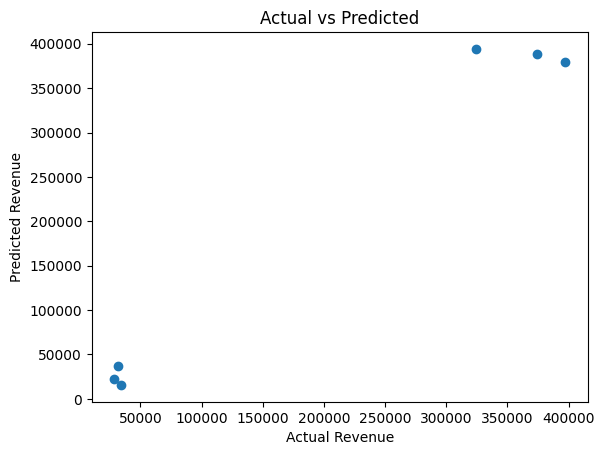

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted")
plt.show()

**Observations**

Model predicts revenue based on given features
If R² score is close to 1 → good model
Errors (MAE, MSE) indicate prediction accuracy

**Conclusion**

Successfully built a Regression Model
Model can be used for sales/revenue prediction
Further improvements:
Use more data
Try advanced models (Decision Tree, Random Forest)